# Intro

1. Notation: $det(A)$ or |abcd|
2. Only square matrices have a determinant
3. Single number that reflects the entire matrix
4. $det(A)=0$ if linearly dependent columns

Determinant tells us how given matrix stretches other tensor in transformation.

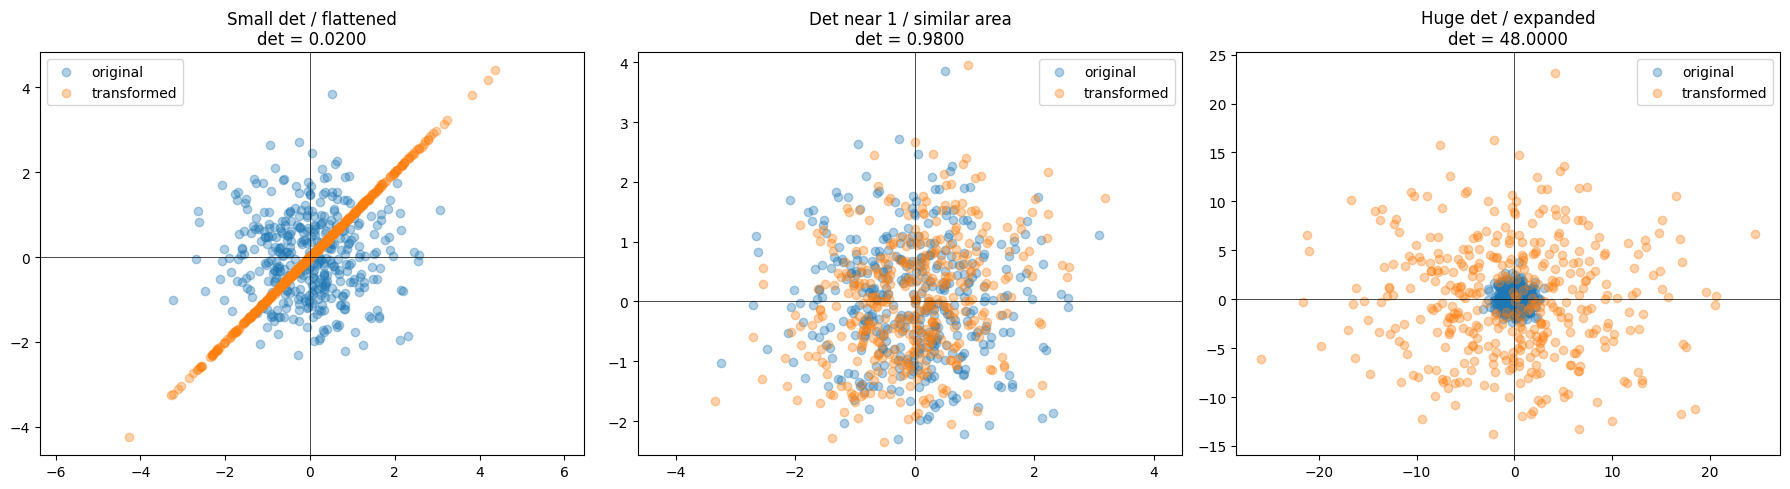

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# punkty 2D
X = np.random.randn(400, 2)

# 1. mały determinant: prawie spłaszcza do linii
A_small = np.array([
    [1.0, 0.99],
    [1.0, 1.01]
])

# 2. determinant około 1: mniej więcej zachowuje pole
A_normal = np.array([
    [1.0, 0.2],
    [0.1, 1.0]
])

# 3. ogromny determinant: mocno rozciąga pole
A_big = np.array([
    [8.0, 0.0],
    [0.0, 6.0]
])

matrices = [
    ("Small det / flattened", A_small),
    ("Det near 1 / similar area", A_normal),
    ("Huge det / expanded", A_big)
]

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

for ax, (title, A) in zip(axs, matrices):
    X_transformed = X @ A

    ax.scatter(X[:, 0], X[:, 1], alpha=0.35, label="original")
    ax.scatter(X_transformed[:, 0], X_transformed[:, 1], alpha=0.35, label="transformed")

    ax.axhline(0, color="black", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=0.5)
    ax.set_title(f"{title}\ndet = {np.linalg.det(A):.4f}")
    ax.axis("equal")
    ax.legend()

plt.tight_layout()
plt.show()

# Determinant applications

* Geometry: Area/volumne of shape specified by coordinates in the matrix
* Matrix inverse: divide by determinant (no inverse if determinant is zero)

# Code

Reduced Rank Matrix if square, it's det is always 0. If rectangular it doesn't have det.

Why?

Reduced Rank Matrix means its columns span a lower-dimensional subspace than $n$ - matrix ambient column dimension, that means whatever is scaled by this matrix going to have smaller dimension. Then if original dimension will be reduced, in this dimension scale of transformation needs to be 0.

The only matrix that can be have $det \neq 0$ needs to be Full Rank Matrix, i.e. $$rank\;==\;matrix\,ambient\,dimension$$

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

A = np.array([[1,3],[1,3]])
np.linalg.det(A)

np.float64(0.0)

In [ ]:
B = np.random.randn(6,6)
B[:,0] = B[:,1]
# B[:,2] = B[:,3]
np.linalg.det(B)

np.float64(0.0)

In [ ]:
B

array([[-0.5176113 , -0.5176113 ,  0.22378795, -0.0164229 ,  1.18839327],
       [-0.53086877, -0.53086877, -0.48943944,  1.04416088,  0.68189149],
       [ 0.58392819,  0.58392819, -0.35929209,  0.59065483,  1.10870358],
       [ 0.50727403,  0.50727403,  1.06667469,  1.16929559,  1.38215899],
       [-0.16711808, -0.16711808,  0.14671369,  1.20650897, -0.81693567]])

In [ ]:
C = np.random.randn(6,6)
print('Before row swap: ' + str(np.linalg.det(C)))

Cs = C[[1, 0, 2, 3, 4, 5], :]
print('After 1 row swap: ' + str(np.linalg.det(Cs)))

Css = C[[1,0,2,4,3,5],:]
print('After 2 row swap: ' + str(np.linalg.det(Css)))

Csss = C[[1,0,2,4,5,3],:]
print('After 3 row swap: ' + str(np.linalg.det(Csss)))

Cssss = C[[1,2,0,4,5,3],:]
print('After 4 row swap: ' + str(np.linalg.det(Cssss)))

Csssss = C[[1,2,0,4,3,5],:]
print('After 5 row swap: ' + str(np.linalg.det(Csssss)))

Cssssss = C[[1,2,4,0,3,5],:]
print('After 6 row swap: ' + str(np.linalg.det(Cssssss)))

Before row swap: -6.569537179547057
After 1 row swap: 6.569537179547057
After 2 row swap: -6.569537179547057
After 3 row swap: 6.569537179547057
After 4 row swap: -6.569537179547057
After 5 row swap: 6.569537179547057
After 6 row swap: -6.569537179547057


Each row swap results in opposite sign.

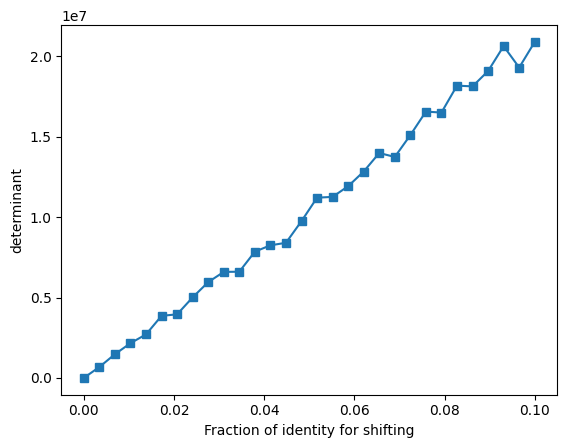

In [ ]:
lambdas = np.linspace(0,.1,30)

# initialize
tmp  = np.zeros(1000)
dets = np.zeros(len(lambdas))

for deti in range(len(lambdas)):
  # run 1000 iters
  for i in range(1000):
    # generate a matrix
    M = np.random.randn(20,20)
    M[:,0] = M[:,1]

    # compute the determinant
    tmp[i] = abs(np.linalg.det(M + lambdas[deti]*np.eye(20)))

  # compute average determinant
  dets[deti] = np.mean(tmp)

plt.plot(lambdas, dets, 's-')
plt.xlabel('Fraction of identity for shifting')
plt.ylabel('determinant')
plt.show()

$$ det(AB) = det(A) * det(B)$$

In [ ]:
E = np.random.randn(30,30)
F = np.random.randn(30,30)

np.linalg.det(E) * np.linalg.det(F)

np.float64(9.28944814061519e+29)

In [ ]:
np.linalg.det(E@F)

np.float64(9.28944814061905e+29)

*Based on a notebook of Mike X Cohen. Notebook was modified.*